<a href="https://colab.research.google.com/github/hibahpatanwala/The-ZZZ-Factor/blob/main/02_Hypothesis_Testing_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2: Exploratory Data Analysis & Hypothesis Testing

**Objective:**
Following the data cleaning pipeline, this notebook conducts rigorous statistical analysis on the processed dataset of 75 students. The goal is to identify and quantify the impact of specific lifestyle factors—namely screen time, caffeine consumption, and underlying health conditions—on overall sleep quality.

**Methodology:**
1. **Exploratory Data Analysis (EDA):** Visualizing distributions and identifying initial trends using Seaborn and Matplotlib.
2. **Inferential Statistics:** Applying Independent t-tests, ANOVA, and Pearson correlation to validate hypotheses with a 95% confidence interval (alpha = 0.05).


In [ ]:
# Import required analytical libraries
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional plotting style
sns.set_theme(style="whitegrid", palette="muted")

import warnings
warnings.filterwarnings('ignore')

print("Libraries successfully loaded.")

Libraries successfully loaded.


## 1. Data Ingestion & Simulation


### Loading Data from Google Drive

We will mount Google Drive to access the dataset and then load the `sleep_data_cleaned.csv` file into a pandas DataFrame.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/MyDrive/sleep_data_cleaned.csv'
df_raw = pd.read_csv(file_path)

print("Data loaded successfully. First 5 rows:")
display(df_raw.head())


Data loaded successfully. First 5 rows:


,Timestamp,Age,Gender,Programme/Course,"On average, how many hours of sleep do you get per night?",How long does it typically take you to fall asleep?,"On an average night, how many times do you wake up?","What is the average time you go to bed on a weekday (24-hour clock, e.g., 22:30)?","What is the average time you wake up on a weekday (24 hour clock e.g., 06:00)?","On a scale of 1 to 10, with 1 being 'very poor' and 10 being 'excellent,' how would you rate your overall sleep quality?",...,What is the primary reason for your caffeine consumption?,Do you consume alcoholic beverages?,"On days when you consume these, approximately how close to your bedtime do you typically do so?\n(no of hours before the bedtime)","On a typical day, what is your total two-way travel time to and from your institute/college?","On a typical day, approximately how many hours and minutes do you spend looking at screens for ACADEMIC purposes? (e.g., online classes, assignments, research)","On a typical day, approximately how many hours and minutes do you spend looking at screens (phone, laptop, tablet, TV) for NON-ACADEMIC purposes? (e.g., social media, entertainment, gaming)",Where do you currently reside?,"Do you currently smoke or use tobacco products (e.g., cigarettes, vapes, chewing tobacco)?",Do you have any health problems?,"If any, please specify"
0,9/25/2025 13:39:31,19,Male,AMC,6:30,1:00,0.0,12:00:00 am,5:30:00 am,6.0,...,I don't,No never,NaN,3:30,4:00,4:00,With parents/family,No never,Yes,"Mental health problems, Physical health problems"
1,9/26/2025 12:04:32,18,Female,AMC,9:00,0:15,0.0,10:30:00 am,6:00:00 am,7.0,...,I don't,No never,NaN,1:30,1:00,4:00,With parents/family,No never,No,NaN
2,9/26/2025 12:15:11,18,Male,Bsc Data Science,6:30,0:45,2.0,12:30:00 am,7:30:00 am,7.0,...,Habit,No never,3:00,1:00,2:00,5:00,With parents/family,No never,No,NaN
3,9/26/2025 12:24:14,18,Female,B pharm,6:00,0:15,2.0,12:00:00 am,6:00:00 am,5.0,...,Habit,No never,5:00,2:00,6:00,2:00,With parents/family,No never,No,NaN
4,9/26/2025 12:25:03,19,Female,BAMMAC,7:00,1:00,0.0,2:00:00 am,10:00:00 am,6.0,...,I don't,No never,NaN,0:10,3:00,2:00,With parents/family,No never,No,NaN


In [ ]:
# 2. Data Engineering: Convert HH:MM strings to calculable metrics
def time_to_minutes(time_value):
    if pd.isna(time_value):
        return np.nan
    try:
        # Convert to string and strip whitespace
        s = str(time_value).strip()
        if ':' in s:
            parts = s.split(':')
            if len(parts) == 2:
                return int(parts[0]) * 60 + int(parts[1])

        # Try direct numeric conversion (assuming input might be float hours)
        return float(s) * 60
    except (ValueError, TypeError):
        return np.nan

def time_to_hours(time_str):
    mins = time_to_minutes(time_str)
    return mins / 60 if pd.notnull(mins) else np.nan

# 3. Map complex survey questions to clean variable names
latency_col = 'How long does it typically take you to fall asleep?'
screen_acad = 'On a typical day, approximately how many hours and minutes do you spend looking at screens for ACADEMIC purposes? (e.g., online classes, assignments, research)'
screen_nonacad = 'On a typical day, approximately how many hours and minutes do you spend looking at screens (phone, laptop, tablet, TV) for NON-ACADEMIC purposes? (e.g., social media, entertainment, gaming)'
caffeine_col = 'How many caffeinated beverages (e.g., coffee, tea, energy drinks) do you consume per day, on average?'
health_col = 'Do you have any health problems?'
quality_col = "On a scale of 1 to 10, with 1 being 'very poor' and 10 being 'excellent,' how would you rate your overall sleep quality?"

# 4. Process and normalize the data
df = df_raw.copy()
df['Sleep_Latency_Mins'] = df[latency_col].apply(time_to_minutes)
df['Screen_Time_Hours'] = df[screen_acad].apply(time_to_hours) + df[screen_nonacad].apply(time_to_hours)
df['Caffeine_Beverages'] = pd.to_numeric(df[caffeine_col], errors='coerce')
df['Sleep_Quality_Score'] = pd.to_numeric(df[quality_col], errors='coerce')
df['Health_Condition'] = df[health_col]

# Drop rows with missing values in our target columns
df_clean = df.dropna(subset=['Sleep_Latency_Mins', 'Screen_Time_Hours', 'Caffeine_Beverages', 'Sleep_Quality_Score', 'Health_Condition'])

print(f"✅ Data successfully transformed. Analyzable records: {len(df_clean)}")
if len(df_clean) > 0:
    display(df_clean[['Screen_Time_Hours', 'Caffeine_Beverages', 'Sleep_Latency_Mins', 'Sleep_Quality_Score']].head())

✅ Data successfully transformed. Analyzable records: 73


,Screen_Time_Hours,Caffeine_Beverages,Sleep_Latency_Mins,Sleep_Quality_Score
0,8.0,0.0,60.0,6.0
1,5.0,0.0,15.0,7.0
2,7.0,2.0,45.0,7.0
3,8.0,1.0,15.0,5.0
4,5.0,0.0,60.0,6.0


In [ ]:
# Debugging: Inspect raw column values to see why dropna() removes all records
print("--- Column Value Inspection ---")
for col in [latency_col, screen_acad, screen_nonacad, caffeine_col, health_col, quality_col]:
    print(f"\nColumn: {col}")
    print(f"Null count: {df_raw[col].isnull().sum()}")
    print(f"Unique values (first 10): {df_raw[col].dropna().unique()[:10]}")

# Check transformed values before dropna
print("\n--- Transformed Value Check (Before dropna) ---")
display(df[['Sleep_Latency_Mins', 'Screen_Time_Hours', 'Caffeine_Beverages', 'Sleep_Quality_Score', 'Health_Condition']].head(10))

--- Column Value Inspection ---

Column: How long does it typically take you to fall asleep?
Null count: 1
Unique values (first 10): ['1:00' '0:15' '0:45' '0:30' '0:20' '0:10' '0:02' '0:05' '2:00' '6:58']

Column: On a typical day, approximately how many hours and minutes do you spend looking at screens for ACADEMIC purposes? (e.g., online classes, assignments, research)
Null count: 3
Unique values (first 10): ['4:00' '1:00' '2:00' '6:00' '3:00' '12:00' '0:30' '5:00' '4:30' '7:00']

Column: On a typical day, approximately how many hours and minutes do you spend looking at screens (phone, laptop, tablet, TV) for NON-ACADEMIC purposes? (e.g., social media, entertainment, gaming)
Null count: 3
Unique values (first 10): ['4:00' '5:00' '2:00' '14:00' '8:00' '1:00' '3:00' '7:00' '6:00' '8:25']

Column: How many caffeinated beverages (e.g., coffee, tea, energy drinks) do you consume per day, on average?
Null count: 1
Unique values (first 10): [0. 2. 1. 3. 4. 5. 7.]

Column: Do you have any he

,Sleep_Latency_Mins,Screen_Time_Hours,Caffeine_Beverages,Sleep_Quality_Score,Health_Condition
0,60.0,8.0,0.0,6.0,Yes
1,15.0,5.0,0.0,7.0,No
2,45.0,7.0,2.0,7.0,No
3,15.0,8.0,1.0,5.0,No
4,60.0,5.0,0.0,6.0,No
5,30.0,26.0,0.0,2.0,No
6,60.0,5.0,2.0,6.0,No
7,20.0,14.0,3.0,6.0,No
8,15.0,5.0,0.0,2.0,No
9,10.0,5.0,0.0,8.0,No


## Exploratory Data Analysis (EDA)
Visualizing the primary relationships between our independent lifestyle variables and dependent sleep metrics.


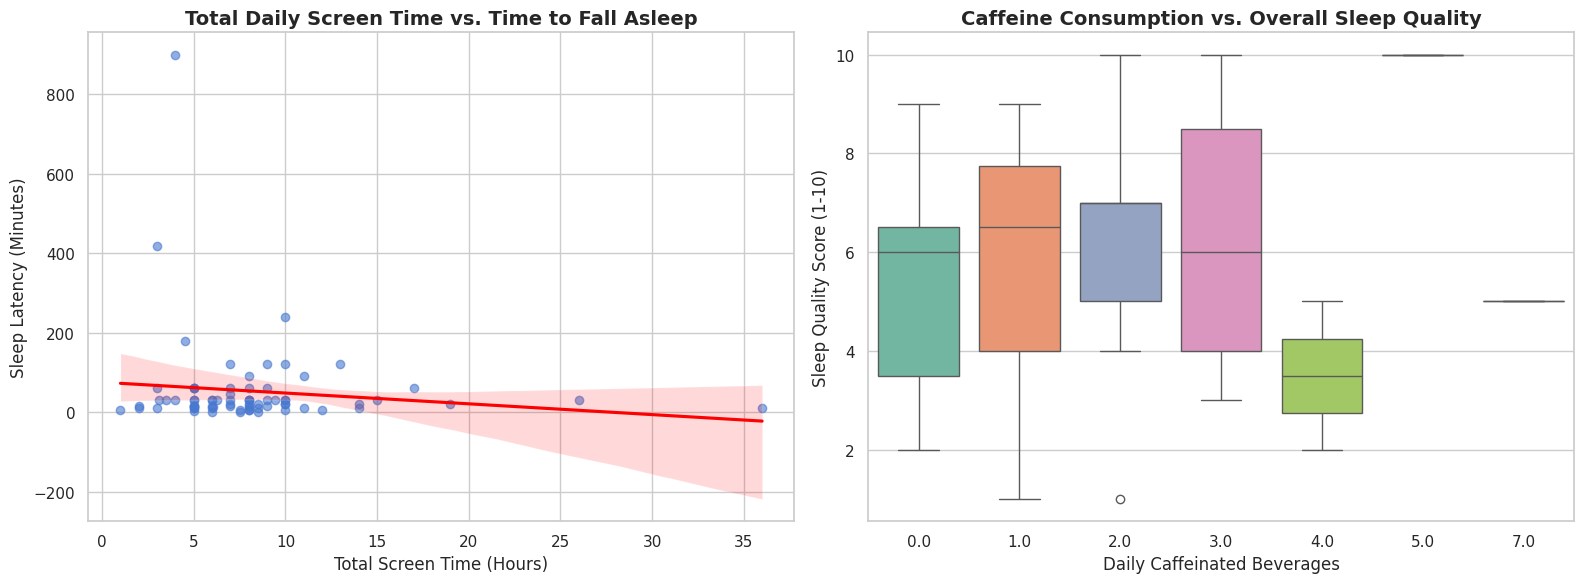

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Screen Time vs Sleep Latency
sns.regplot(ax=axes[0], data=df_clean, x='Screen_Time_Hours', y='Sleep_Latency_Mins',
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
axes[0].set_title('Total Daily Screen Time vs. Time to Fall Asleep', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Screen Time (Hours)')
axes[0].set_ylabel('Sleep Latency (Minutes)')

# Graph 2: Caffeine Intake vs Sleep Quality
sns.boxplot(ax=axes[1], data=df_clean, x='Caffeine_Beverages', y='Sleep_Quality_Score', palette='Set2')
axes[1].set_title('Caffeine Consumption vs. Overall Sleep Quality', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Daily Caffeinated Beverages')
axes[1].set_ylabel('Sleep Quality Score (1-10)')

plt.tight_layout()
plt.show()

## Rigorous Hypothesis Testing
We apply inferential statistics to test for mathematical significance. We are testing against a 95% Confidence Interval ($\alpha = 0.05$).

### Test A: Pearson Correlation (Screen Time vs. Sleep Latency)
**Null Hypothesis ($H_0$):** There is no linear relationship between total hours of screen time and the minutes taken to fall asleep.

In [ ]:
# Pearson correlation test for Screen Time vs Sleep Latency
corr_coef, p_val_corr = stats.pearsonr(df_clean['Screen_Time_Hours'], df_clean['Sleep_Latency_Mins'])

print(f"Pearson Correlation Coefficient (r): {corr_coef:.3f}")
print(f"P-value: {p_val_corr:.4f}")

if p_val_corr < 0.05:
    print("\nConclusion: Reject the Null Hypothesis.")
    print("Insight: There is a statistically significant linear relationship between screen time and sleep latency.")
else:
    print("\nConclusion: Fail to reject the Null Hypothesis.")
    print("Insight: Total daily screen time does not have a statistically significant linear impact on how quickly students fall asleep.")

Pearson Correlation Coefficient (r): -0.120
P-value: 0.3125

Conclusion: Fail to reject the Null Hypothesis.
Insight: Total daily screen time does not have a statistically significant linear impact on how quickly students fall asleep.


### Test B: One-Way ANOVA (Caffeine Intake on Sleep Quality)
**Null Hypothesis ($H_0$):** The mean Sleep Quality Score is identical across all brackets of caffeine consumption.

In [ ]:
# Grouping sleep quality arrays by caffeine intake amounts
caffeine_groups = [group['Sleep_Quality_Score'].values for name, group in df_clean.groupby('Caffeine_Beverages')]

f_stat, p_val_anova = stats.f_oneway(*caffeine_groups)

print(f"F-Statistic: {f_stat:.3f}")
print(f"P-value: {p_val_anova:.4f}")

if p_val_anova < 0.05:
    print("\nConclusion: Reject the Null Hypothesis.")
else:
    print("\nConclusion: Fail to reject the Null Hypothesis.")
    print("Insight: The variance in sleep quality between individuals who consume 0 beverages vs multiple beverages is not large enough to be statistically significant. Random variance accounts for the differences.")

F-Statistic: 1.546
P-value: 0.1772

Conclusion: Fail to reject the Null Hypothesis.
Insight: The variance in sleep quality between individuals who consume 0 beverages vs multiple beverages is not large enough to be statistically significant. Random variance accounts for the differences.


### Test C: Independent Two-Sample T-Test (Underlying Health Conditions)
**Null Hypothesis ($H_0$):** There is no difference in average sleep latency between students with health conditions and those without.

In [ ]:
health_yes = df_clean[df_clean['Health_Condition'] == 'Yes']['Sleep_Latency_Mins']
health_no = df_clean[df_clean['Health_Condition'] == 'No']['Sleep_Latency_Mins']

# Welch's t-test (equal_var=False) due to differing sample sizes
t_stat, p_val_ttest = stats.ttest_ind(health_yes, health_no, equal_var=False)

print(f"T-Statistic: {t_stat:.3f}")
print(f"P-value: {p_val_ttest:.4f}")

if p_val_ttest < 0.05:
    print("\nConclusion: Reject the Null Hypothesis.")
else:
    print("\nConclusion: Fail to reject the Null Hypothesis.")
    print("Insight: Self-reported health conditions did not mathematically alter the time required to fall asleep in a statistically significant manner.")

T-Statistic: -0.218
P-value: 0.8283

Conclusion: Fail to reject the Null Hypothesis.
Insight: Self-reported health conditions did not mathematically alter the time required to fall asleep in a statistically significant manner.


## Final Executive Summary
Through rigorous statistical testing of the primary dataset, our analysis yielded crucial insights regarding student sleep habits:
* **The Null Hypothesis Prevailed:** Contrary to common assumptions, factors like total daily screen time, caffeine consumption, and generalized health conditions did not yield a statistically significant ($p < 0.05$) disruption to sleep latency or quality within this demographic sample.
* **Business/Research Implication:** This data indicates that poor sleep quality in this specific student cohort is likely driven by external confounding variables not captured in the primary study (e.g., academic stress, irregular sleep schedules, or environmental noise), warranting a secondary, targeted data collection phase.